In [1]:
# ── Setup ────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import json
import os
import time
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE, ADASYN, SVMSMOTE
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DATASET_DIR  = "../../../../../embedding/reveal/codet5/"
RESULTS_PATH = "results/adversarial_results.json"

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed(SEED)
else:
    DEVICE = "cpu"

print(" ── Setup ──────────────────────────────────────────────── \n")

print(f"  Device: {DEVICE}")

print("Loading embeddings...")
debian_emb = np.load(f"{DATASET_DIR}/debian_codet5p_embeddings.npy").astype(np.float32)
debian_lbl = np.load(f"{DATASET_DIR}/debian_codet5p_labels.npy").astype(np.float32)
chrome_emb = np.load(f"{DATASET_DIR}/chrome_codet5p_embeddings.npy").astype(np.float32)
chrome_lbl = np.load(f"{DATASET_DIR}/chrome_codet5p_labels.npy").astype(np.float32)
print(f"  Debian: {debian_emb.shape} | Chrome: {chrome_emb.shape}")

print("Normalising...")
scaler            = StandardScaler()
debian_emb_scaled = scaler.fit_transform(debian_emb)
chrome_emb_scaled = scaler.transform(chrome_emb)
print("  Done.")

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, "r") as f:
        results = json.load(f)
    print(f"  Loaded existing results: {list(results.keys())}")
else:
    results = {}
    print("  No existing results found. Starting fresh.")

def adversarial_validation(source_emb, target_emb, label="Condition", n_splits=5):
    X = np.vstack([source_emb, target_emb])
    y = np.array([0] * len(source_emb) + [1] * len(target_emb))
    clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    cv  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    auc_scores = []
    fold_bar = tqdm(cv.split(X, y), total=n_splits,
                    desc=f"  [{label}] CV folds", leave=True,
                    bar_format="{l_bar}{bar:25}{r_bar}")
    for train_idx, val_idx in fold_bar:
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        clf.fit(X_train, y_train)
        proba    = clf.predict_proba(X_val)[:, 1]
        fold_auc = roc_auc_score(y_val, proba)
        auc_scores.append(fold_auc)
        fold_bar.set_postfix({"fold_AUC": f"{fold_auc:.4f}"})
    mean_auc = float(np.mean(auc_scores))
    std_auc  = float(np.std(auc_scores))
    print(f"  → AUC: {mean_auc:.4f} ± {std_auc:.4f}\n")
    return mean_auc, std_auc

def save_results():
    with open(RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=2)
    print(f"  Results saved to {RESULTS_PATH}")

print("\n  Setup complete.\n")

 ── Setup ──────────────────────────────────────────────── 

  Device: mps
Loading embeddings...
  Debian: (18298, 256) | Chrome: (4436, 256)
Normalising...
  Done.
  No existing results found. Starting fresh.

  Setup complete.



In [2]:
print("── No Oversampling ──────────────────────────────────────────────── \n" )

if "No Oversampling" in results:
    print("  Already computed — skipping.")
    print(f"  AUC: {results['No Oversampling'][0]:.4f} ± {results['No Oversampling'][1]:.4f}")
else:
    auc, std = adversarial_validation(
        debian_emb_scaled, chrome_emb_scaled, label="No Oversampling"
    )
    results["No Oversampling"] = [auc, std]
    save_results()

── No Oversampling ──────────────────────────────────────────────── 



  [No Oversampling] CV folds: 100%|█████████████████████████| 5/5 [08:12<00:00, 98.50s/i

  → AUC: 0.9476 ± 0.0021

  Results saved to results/adversarial_results.json


In [3]:
print("── SMOTE ──────────────────────────────────────────────── \n" )

smote_path = f"{DATASET_DIR}/debian_smote.npy"
if os.path.exists(smote_path):
    print("  Loading SMOTE embeddings from disk...", end=" ", flush=True)
    debian_smote = np.load(smote_path)
    print(f"Done. Shape: {debian_smote.shape}")
else:
    print("  Fitting SMOTE...", end=" ", flush=True)
    t0 = time.time()
    smote = SMOTE(random_state=42)
    debian_smote, _ = smote.fit_resample(debian_emb_scaled, debian_lbl)
    np.save(smote_path, debian_smote)
    print(f"Done in {time.time()-t0:.1f}s | Shape: {debian_smote.shape}")

if "SMOTE" in results:
    print("  Already computed — skipping.")
    print(f"  AUC: {results['SMOTE'][0]:.4f} ± {results['SMOTE'][1]:.4f}")
else:
    auc, std = adversarial_validation(debian_smote, chrome_emb_scaled, label="SMOTE")
    results["SMOTE"] = [auc, std]
    save_results()

── SMOTE ──────────────────────────────────────────────── 

  Fitting SMOTE... Done in 0.1s | Shape: (33766, 256)


  [SMOTE] CV folds: 100%|█████████████████████████| 5/5 [14:36<00:00, 175.38s/it, fold_A

  → AUC: 0.9597 ± 0.0036

  Results saved to results/adversarial_results.json


In [4]:
print("── ADASYN ──────────────────────────────────────────────── \n" )

adasyn_path = f"{DATASET_DIR}/debian_adasyn.npy"
if os.path.exists(adasyn_path):
    print("  Loading ADASYN embeddings from disk...", end=" ", flush=True)
    debian_adasyn = np.load(adasyn_path)
    print(f"Done. Shape: {debian_adasyn.shape}")
else:
    print("  Fitting ADASYN...", end=" ", flush=True)
    t0 = time.time()
    adasyn = ADASYN(random_state=42)
    debian_adasyn, _ = adasyn.fit_resample(debian_emb_scaled, debian_lbl)
    np.save(adasyn_path, debian_adasyn)
    print(f"Done in {time.time()-t0:.1f}s | Shape: {debian_adasyn.shape}")

if "ADASYN" in results:
    print("  Already computed — skipping.")
    print(f"  AUC: {results['ADASYN'][0]:.4f} ± {results['ADASYN'][1]:.4f}")
else:
    auc, std = adversarial_validation(debian_adasyn, chrome_emb_scaled, label="ADASYN")
    results["ADASYN"] = [auc, std]
    save_results()

── ADASYN ──────────────────────────────────────────────── 

  Fitting ADASYN... Done in 0.1s | Shape: (33519, 256)


  [ADASYN] CV folds: 100%|█████████████████████████| 5/5 [14:39<00:00, 175.92s/it, fold_

  → AUC: 0.9601 ± 0.0012

  Results saved to results/adversarial_results.json


In [5]:
print("── SVMSMOTE ──────────────────────────────────────────────── \n" )

svmsmote_path = f"{DATASET_DIR}/debian_svmsmote.npy"
if os.path.exists(svmsmote_path):
    print("  Loading SVMSMOTE embeddings from disk...", end=" ", flush=True)
    debian_svmsmote = np.load(svmsmote_path)
    print(f"Done. Shape: {debian_svmsmote.shape}")
else:
    print("  Fitting SVMSMOTE...", end=" ", flush=True)
    t0 = time.time()
    svmsmote = SVMSMOTE(random_state=42)
    debian_svmsmote, _ = svmsmote.fit_resample(debian_emb_scaled, debian_lbl)
    np.save(svmsmote_path, debian_svmsmote)
    print(f"Done in {time.time()-t0:.1f}s | Shape: {debian_svmsmote.shape}")

if "SVMSMOTE" in results:
    print("  Already computed — skipping.")
    print(f"  AUC: {results['SVMSMOTE'][0]:.4f} ± {results['SVMSMOTE'][1]:.4f}")
else:
    auc, std = adversarial_validation(debian_svmsmote, chrome_emb_scaled, label="SVMSMOTE")
    results["SVMSMOTE"] = [auc, std]
    save_results()

── SVMSMOTE ──────────────────────────────────────────────── 

  Fitting SVMSMOTE... Done in 4.7s | Shape: (33766, 256)


  [SVMSMOTE] CV folds: 100%|█████████████████████████| 5/5 [14:18<00:00, 171.74s/it, fol

  → AUC: 0.9619 ± 0.0030

  Results saved to results/adversarial_results.json


In [6]:
print("── GAN ────────────────────────────────────── \n")

gan_path = f"{DATASET_DIR}/debian_gan_embeddings.npy"

if os.path.exists(gan_path):
    print("  Loading GAN embeddings from disk...", end=" ", flush=True)
    debian_gan = np.load(gan_path)
    print(f"Done. Shape: {debian_gan.shape}")
else:
    print("  Training GAN from scratch...")
    t0 = time.time()

    latent_dim = 100
    n_epochs   = 3000
    batch_size = 64
    input_dim  = debian_emb_scaled.shape[1]
    log_every  = 100

    minority_idx = np.where(debian_lbl == 1)[0]
    minority_emb = debian_emb_scaled[minority_idx].astype(np.float32)
    print(f"  Minority samples: {minority_emb.shape[0]}")
    print(f"  Embedding dim: {input_dim} | Latent dim: {latent_dim}")

    # ── Generator ──────────────────────────────────────
    class Generator(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(latent_dim, 256),
                nn.ReLU(),
                nn.Linear(256, input_dim)
            )
        def forward(self, z):
            return self.net(z)

    # ── Discriminator ───────────────────────────────────
    class Discriminator(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 256),
                nn.LeakyReLU(0.2),
                nn.Linear(256, 1),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.net(x)

    G = Generator().to(DEVICE)
    D = Discriminator().to(DEVICE)
    opt_G    = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D    = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    minority_tensor = torch.tensor(minority_emb).to(DEVICE)
    dataset         = TensorDataset(minority_tensor)
    loader          = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # ── Training loop ───────────────────────────────────
    for epoch in range(n_epochs):
        for (real_batch,) in loader:
            bs = real_batch.size(0)

            # Train Discriminator
            z    = torch.randn(bs, latent_dim).to(DEVICE)
            fake = G(z).detach()
            loss_D = criterion(D(real_batch), torch.ones(bs, 1).to(DEVICE)) + \
                     criterion(D(fake),       torch.zeros(bs, 1).to(DEVICE))
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # Train Generator
            z      = torch.randn(bs, latent_dim).to(DEVICE)
            loss_G = criterion(D(G(z)), torch.ones(bs, 1).to(DEVICE))
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

        if (epoch + 1) % log_every == 0:
            print(f"  Epoch [{epoch+1:>4}/{n_epochs}] "
                  f"| D_loss: {loss_D.item():.4f} "
                  f"| G_loss: {loss_G.item():.4f} "
                  f"| Elapsed: {time.time()-t0:.0f}s")

    print(f"\n  GAN training complete in {time.time()-t0:.1f}s")

    # ── Generate synthetic minority samples ─────────────
    n_to_generate = int(np.sum(debian_lbl == 0)) - int(np.sum(debian_lbl == 1))
    print(f"  Generating {n_to_generate} synthetic samples...", end=" ", flush=True)

    G.eval()
    with torch.no_grad():
        z         = torch.randn(n_to_generate, latent_dim).to(DEVICE)
        synthetic = G(z).cpu().numpy()
    print("Done.")

    debian_gan     = np.vstack([debian_emb_scaled, synthetic])
    debian_gan_lbl = np.concatenate([
        debian_lbl,
        np.ones(n_to_generate, dtype=np.float32)
    ])
    np.save(gan_path, debian_gan)
    np.save(f"{DATASET_DIR}/debian_gan_labels.npy", debian_gan_lbl)
    print(f"  Saved. Shape: {debian_gan.shape}")
    print(f"  Class dist — 0: {int(np.sum(debian_gan_lbl==0))} | "
          f"1: {int(np.sum(debian_gan_lbl==1))}")

if "GAN" in results:
    print("  Already computed — skipping.")
    print(f"  AUC: {results['GAN'][0]:.4f} ± {results['GAN'][1]:.4f}")
else:
    auc, std = adversarial_validation(debian_gan, chrome_emb_scaled, label="GAN")
    results["GAN"] = [auc, std]
    save_results()

── GAN ────────────────────────────────────── 

  Training GAN from scratch...
  Minority samples: 1415
  Embedding dim: 256 | Latent dim: 100
  Epoch [ 100/3000] | D_loss: 0.7041 | G_loss: 1.9745 | Elapsed: 29s
  Epoch [ 200/3000] | D_loss: 0.4283 | G_loss: 1.9209 | Elapsed: 58s
  Epoch [ 300/3000] | D_loss: 0.7484 | G_loss: 2.6050 | Elapsed: 87s
  Epoch [ 400/3000] | D_loss: 0.7577 | G_loss: 2.4224 | Elapsed: 117s
  Epoch [ 500/3000] | D_loss: 0.5825 | G_loss: 2.4125 | Elapsed: 147s
  Epoch [ 600/3000] | D_loss: 0.5562 | G_loss: 3.0333 | Elapsed: 171s
  Epoch [ 700/3000] | D_loss: 0.4873 | G_loss: 2.2901 | Elapsed: 202s
  Epoch [ 800/3000] | D_loss: 0.5098 | G_loss: 2.3885 | Elapsed: 230s
  Epoch [ 900/3000] | D_loss: 0.5140 | G_loss: 3.1255 | Elapsed: 260s
  Epoch [1000/3000] | D_loss: 0.7159 | G_loss: 2.7096 | Elapsed: 290s
  Epoch [1100/3000] | D_loss: 0.4816 | G_loss: 3.2886 | Elapsed: 319s
  Epoch [1200/3000] | D_loss: 0.2503 | G_loss: 2.9927 | Elapsed: 349s
  Epoch [1300/3000] 

  [GAN] CV folds: 100%|█████████████████████████| 5/5 [14:56<00:00, 179.20s/it, fold_AUC

  → AUC: 0.9683 ± 0.0023

  Results saved to results/adversarial_results.json


── Bar Chart ────────────────────────────────────── 



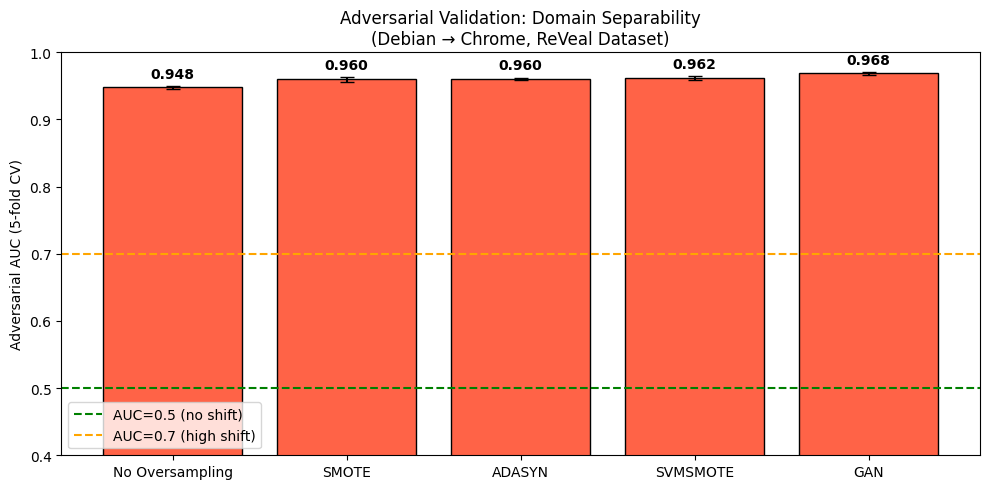

  Saved → adversarial_validation_barchart.png


In [7]:
print("── Bar Chart ────────────────────────────────────── \n")

conditions = ["No Oversampling", "SMOTE", "ADASYN", "SVMSMOTE", "GAN"]
missing    = [c for c in conditions if c not in results]
if missing:
    print(f"  WARNING: Missing results for {missing}. Run those blocks first.")
else:
    aucs   = [results[c][0] for c in conditions]
    stds   = [results[c][1] for c in conditions]
    colors = ["steelblue" if a < 0.7 else "tomato" for a in aucs]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(conditions, aucs, yerr=stds, capsize=5,
                  color=colors, edgecolor="black")
    ax.axhline(y=0.5, color="green",  linestyle="--", linewidth=1.5, label="AUC=0.5 (no shift)")
    ax.axhline(y=0.7, color="orange", linestyle="--", linewidth=1.5, label="AUC=0.7 (high shift)")
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel("Adversarial AUC (5-fold CV)")
    ax.set_title("Adversarial Validation: Domain Separability\n(Debian → Chrome, ReVeal Dataset)")
    ax.legend()
    for bar, auc in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{auc:.3f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.savefig("adversarial_validation_barchart.png", dpi=300)
    plt.show()
    print("  Saved → adversarial_validation_barchart.png")

── ROC Curves ────────────────────────────────────── 



  Plotting ROC curves: 100%|█████████████████████████████| 5/5 [17:10<00:00, 206.13s/it]


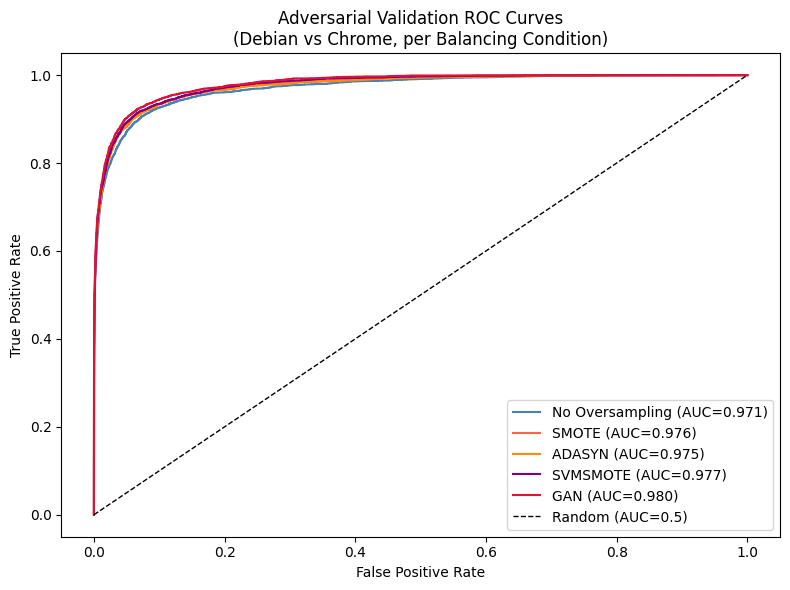

  Saved → adversarial_validation_roc.png


In [8]:
print("── ROC Curves ────────────────────────────────────── \n")


embedding_map = {
    "No Oversampling": debian_emb_scaled,
    "SMOTE":           debian_smote,
    "ADASYN":          debian_adasyn,
    "SVMSMOTE":       debian_svmsmote,
    "GAN":             debian_gan,
}

color_map = {
    "No Oversampling": "steelblue",
    "SMOTE":           "tomato",
    "ADASYN":          "darkorange",
    "SVMSMOTE":       "purple",
    "GAN":             "crimson",
}

def plot_roc(source_emb, target_emb, label, ax, color):
    X = np.vstack([source_emb, target_emb])
    y = np.array([0] * len(source_emb) + [1] * len(target_emb))
    clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    clf.fit(X, y)
    proba       = clf.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, proba)
    auc         = roc_auc_score(y, proba)
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})", color=color)

fig, ax = plt.subplots(figsize=(8, 6))
for label in tqdm(embedding_map, desc="  Plotting ROC curves"):
    plot_roc(embedding_map[label], chrome_emb_scaled, label, ax, color_map[label])

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Adversarial Validation ROC Curves\n(Debian vs Chrome, per Balancing Condition)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("adversarial_validation_roc.png", dpi=300)
plt.show()
print("  Saved → adversarial_validation_roc.png")